Kurtosis for Separated-1: 6.12
Kurtosis for Separated-2: 3.52


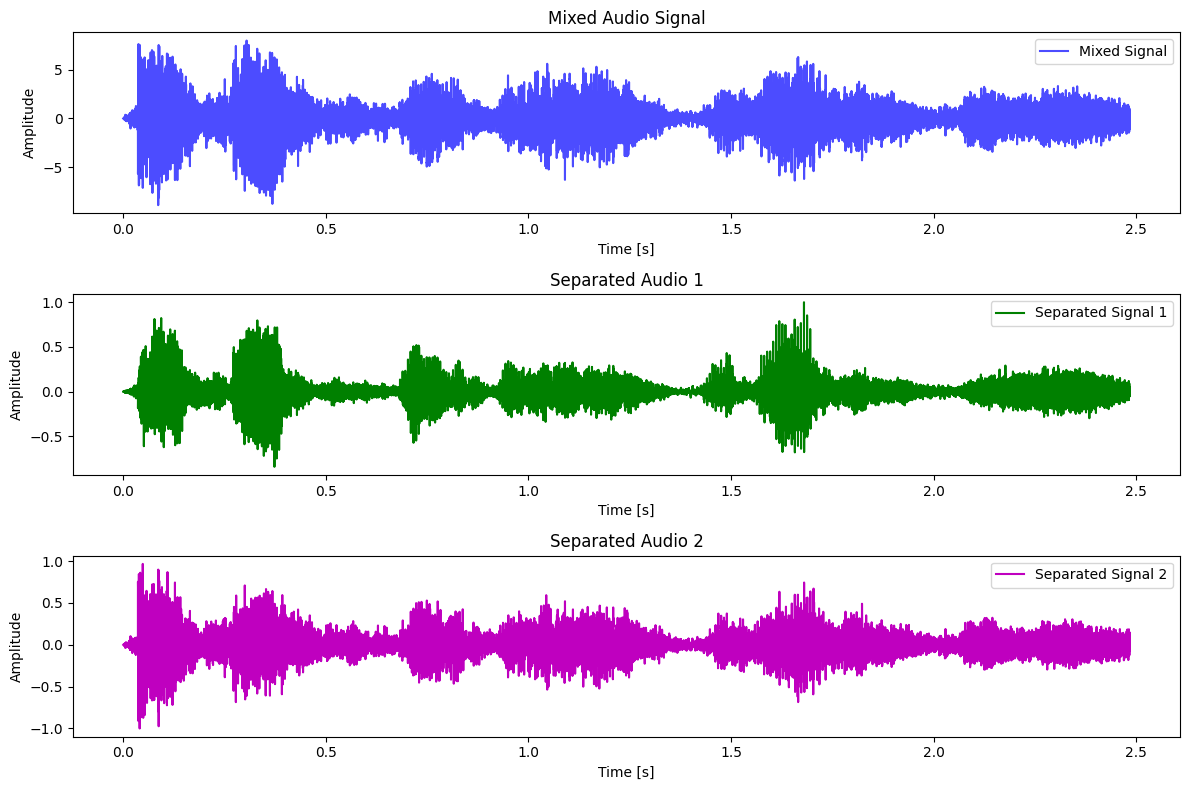

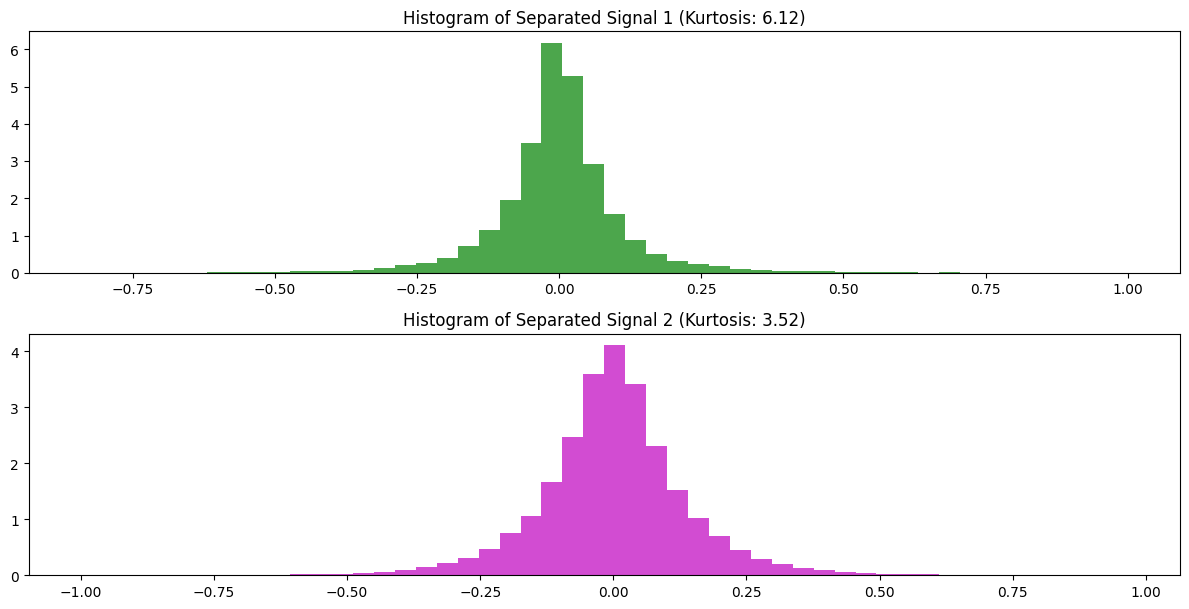

In [ ]:
import numpy as np
import scipy.io.wavfile as wav
import soundfile as sf
import matplotlib.pyplot as plt
from scipy.stats import kurtosis

def load_audio(file_path):
    rate, data = wav.read(file_path)
    return rate, data.astype(np.float32)

def save_audio(file_path, data, rate):
    sf.write(file_path, data, rate)

def center(X):
    return X - np.mean(X, axis=0)

def apply_pca(X, n_components):
    mean = np.mean(X, axis=0)
    X_centered = X - mean
    U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
    X_pca = X_centered @ Vt[:n_components].T
    return X_pca

def whiten(X):
    cov = np.cov(X.T)
    eigvals, eigvecs = np.linalg.eigh(cov)
    D = np.diag(1.0 / np.sqrt(eigvals + 1e-10))
    X_whitened = X @ eigvecs @ D @ eigvecs.T
    return X_whitened

def fast_ica(X, n_components=2, max_iter=1000, tol=1e-6, a1=1.0):
    def g(x):
        return (1 / a1) * np.log(np.cosh(a1 * x))

    def g_derivative(x):
        return np.tanh(a1 * x)

    n_samples, n_features = X.shape
    W = np.random.randn(n_components, n_features)

    for i in range(n_components):
        w = W[i, :].copy()

        for iteration in range(max_iter):
            w_new = np.mean(X.T @ g(X @ w)[:, np.newaxis], axis=1).flatten()
            w_new -= np.mean(g_derivative(X @ w)) * w

            w_new /= np.linalg.norm(w_new)

            for j in range(i):
                w_new -= np.dot(w_new, W[j]) * W[j]

            w_new /= np.linalg.norm(w_new)

            if np.linalg.norm(w_new - w) < tol:
                break

            w = w_new

        W[i, :] = w

    return W

def compute_kurtosis(X):
    return kurtosis(X, fisher=True)

input_audio = r"/content/Untitled_Project_V2 (2).wav"
output_audio_1 = r"/content/separated_1.wav"
output_audio_2 = r"/content/separated_2.wav"

rate, mixed_audio = load_audio(input_audio)

if mixed_audio.ndim == 1 or mixed_audio.shape[1] < 2:
    raise ValueError("Audio file must have at least two channels for ICA.")

mixed_audio = center(mixed_audio)
mixed_audio = apply_pca(mixed_audio, n_components=2)
mixed_audio = whiten(mixed_audio)

W = fast_ica(mixed_audio, n_components=2, a1=5.0)
separated_audio = np.dot(mixed_audio, W.T)

separated_audio /= np.max(np.abs(separated_audio), axis=0)

save_audio(output_audio_1, separated_audio[:, 0], rate)
save_audio(output_audio_2, separated_audio[:, 1], rate)

kurtosis_1 = compute_kurtosis(separated_audio[:, 0])
kurtosis_2 = compute_kurtosis(separated_audio[:, 1])

print(f"Kurtosis for Separated-1: {kurtosis_1:.2f}")
print(f"Kurtosis for Separated-2: {kurtosis_2:.2f}")

time = np.linspace(0, len(mixed_audio) / rate, num=len(mixed_audio))

plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(time, mixed_audio.sum(axis=1), label="Mixed Signal", color='b', alpha=0.7)
plt.title("Mixed Audio Signal")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(time, separated_audio[:, 0], label="Separated Signal 1", color='g')
plt.title("Separated Audio 1")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(time, separated_audio[:, 1], label="Separated Signal 2", color='m')
plt.title("Separated Audio 2")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 9))

plt.subplot(3, 1, 2)
plt.hist(separated_audio[:, 0], bins=50, color='g', alpha=0.7, density=True)
plt.title(f"Histogram of Separated Signal 1 (Kurtosis: {kurtosis_1:.2f})")

plt.subplot(3, 1, 3)
plt.hist(separated_audio[:, 1], bins=50, color='m', alpha=0.7, density=True)
plt.title(f"Histogram of Separated Signal 2 (Kurtosis: {kurtosis_2:.2f})")

plt.tight_layout()
plt.show()
